# SVM Simple con Datos Académicos Reales

**Machine Learning 1 — FIUNA**

**Docente:** Diego Stalder | **Práctica:** Carlos Benítez

---

## Objetivo

Aplicar un **SVM lineal y con kernel RBF** para predecir la variable binaria **`Remontada`** (si un estudiante mejora su desempeño en la materia siguiente), usando el mismo dataset académico de la práctica anterior.

**Comparación directa:** Regresión Logística (modelo base) vs SVM (kernel lineal y RBF).

## Estructura

1. **Carga y filtrado de datos** (Ecuaciones Diferenciales + Cálculo 2)
2. **Definición de la variable objetivo** `Remontada`
3. **Preparación de features**
4. **SVM con kernel lineal** (frontera recta)
5. **SVM con kernel RBF** (frontera curva)
6. **Comparación con Regresión Logística**
7. **Visualización de fronteras de decisión**
8. **Interpretación de los resultados**

## 0. Importaciones y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100
})
sns.set_palette('husl')
np.random.seed(42)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - SVM")
print("🎯 Variable objetivo: Remontada")
print("="*80)

📊 PREDICCIÓN DE APROBACIÓN - SVM
🎯 Variable objetivo: Remontada


## 1. Carga y Filtrado de Datos

Cargamos el dataset concatenado y filtramos las materias relevantes:
- **Ecuaciones Diferenciales** (materia previa)
- **Cálculo 2** (materia siguiente)

Hacemos un merge por `ALUMNO_ID` para tener ambas materias por estudiante.

In [2]:
# Cargar datos
df = pd.read_csv(r'D:\ArchivosHDD\GitHub\Machine-Learning\Clase_4\datos_concatenados.csv')
print(f"✅ Datos cargados: {len(df):,} registros")

# Filtrar Ecuaciones Diferenciales
mask_ed = df['Asignatura'].str.upper().str.contains('ECUACIONES DIFERENCIALES', na=False)
df_ed = df[mask_ed].copy()
print(f"\n📘 Ecuaciones Diferenciales: {len(df_ed):,} registros, {df_ed['ALUMNO_ID'].nunique():,} estudiantes")

# Filtrar Cálculo 2
mask_c2 = df['Asignatura'].str.upper().str.contains('CALCULO 2', na=False)
df_c2 = df[mask_c2].copy()
print(f"📗 Cálculo 2: {len(df_c2):,} registros, {df_c2['ALUMNO_ID'].nunique():,} estudiantes")

# Definir variable objetivo: Remontada
# Remontada = True si Segundo.Par > Primer.Par Y Firma > 50
mask_remontada = df_ed['Segundo.Par'] > df_ed['Primer.Par']
mask_firma = df_ed['Firma'] > 50
df_ed['Remontada'] = mask_remontada & mask_firma

print(f"\n🎯 Variable 'Remontada':")
print(df_ed['Remontada'].value_counts())
print(f"Tasa de remontada: {df_ed['Remontada'].mean()*100:.1f}%")

✅ Datos cargados: 72,740 registros

📘 Ecuaciones Diferenciales: 1,245 registros, 972 estudiantes
📗 Cálculo 2: 892 registros, 892 estudiantes

🎯 Variable 'Remontada':
Remontada
False    1059
True      186
Name: count, dtype: int64
Tasa de remontada: 14.9%


## 2. Merge y Preparación de Features

Unimos ambos dataframes por `ALUMNO_ID` para tener las características de Ecuaciones Diferenciales y la etiqueta `Remontada`.

In [3]:
# Merge por alumno
merged = df_ed.merge(df_c2, on='ALUMNO_ID', how='inner', suffixes=('_ed', '_c2'))
print(f"✅ Registros después del merge: {len(merged):,}")

# Definir features: notas de Ecuaciones Diferenciales
feature_cols = ['Primer.Par_ed', 'Segundo.Par_ed', 'TPLab._ed', 'Firma_ed', 'Primer.Rec_ed']
X = merged[feature_cols].copy()
y = merged['Remontada'].astype(int)

# Limpiar datos: convertir a numérico y eliminar NaN
for col in feature_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

mask_valid = ~X.isnull().any(axis=1)
X = X[mask_valid].reset_index(drop=True)
y = y[mask_valid].reset_index(drop=True)

print(f"\n📊 Dataset final: {len(X)} estudiantes, {X.shape[1]} características")
print(f"Distribución de clases:")
print(y.value_counts())
print(f"\nPrimeras filas:")
X.head()

✅ Registros después del merge: 304

📊 Dataset final: 304 estudiantes, 5 características
Distribución de clases:
Remontada
0    276
1     28
Name: count, dtype: int64

Primeras filas:


,Primer.Par_ed,Segundo.Par_ed,TPLab._ed,Firma_ed,Primer.Rec_ed
0,42,58,70,52.0,0
1,42,58,70,52.0,0
2,69,71,50,68.0,21
3,69,71,50,68.0,21
4,0,0,30,0.0,0


## 3. División Train/Test

Dividimos en 70% entrenamiento y 30% prueba, estratificando por la variable objetivo.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train)} muestras (Remontada: {y_train.mean()*100:.1f}%)")
print(f"Prueba:        {len(X_test)} muestras (Remontada: {y_test.mean()*100:.1f}%)")

Entrenamiento: 212 muestras (Remontada: 9.4%)
Prueba:        92 muestras (Remontada: 8.7%)


## 4. SVM con Kernel Lineal

**Idea:** Buscar un hiperplano que separe las clases con el margen máximo.

**Ecuación fundamental:** $\min_{\mathbf{w}, b} \frac{1}{2}\|\mathbf{w}\|^2$ sujeto a $y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1$

In [5]:
# Pipeline: escalado + SVM lineal
pipeline_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
])

# Entrenar
pipeline_linear.fit(X_train, y_train)

# Predecir
y_pred_lin = pipeline_linear.predict(X_test)
y_prob_lin = pipeline_linear.decision_function(X_test)

acc_lin = accuracy_score(y_test, y_pred_lin)
auc_lin = roc_auc_score(y_test, y_prob_lin)

print("="*80)
print("🔷 SVM CON KERNEL LINEAL")
print("="*80)
print(f"Accuracy en test: {acc_lin*100:.2f}%")
print(f"AUC-ROC:          {auc_lin:.4f}")
print(f"\nVectores de soporte: {len(pipeline_linear.named_steps['svm'].support_vectors_)}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_lin, target_names=['No Remontada', 'Remontada']))

🔷 SVM CON KERNEL LINEAL
Accuracy en test: 98.91%
AUC-ROC:          0.9926

Vectores de soporte: 48

Reporte de clasificación:
              precision    recall  f1-score   support

No Remontada       1.00      0.99      0.99        84
   Remontada       0.89      1.00      0.94         8

    accuracy                           0.99        92
   macro avg       0.94      0.99      0.97        92
weighted avg       0.99      0.99      0.99        92



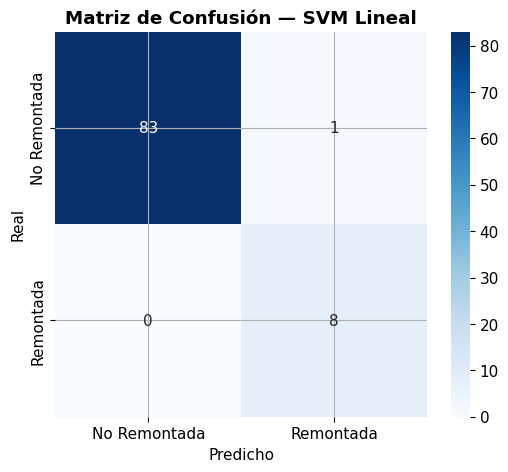

In [6]:
# Matriz de confusión SVM lineal
cm_lin = confusion_matrix(y_test, y_pred_lin)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Remontada', 'Remontada'],
            yticklabels=['No Remontada', 'Remontada'])
plt.title('Matriz de Confusión — SVM Lineal', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## 5. SVM con Kernel RBF (No Lineal)

**Idea:** Mapear implícitamente los datos a un espacio de mayor dimensión donde sí sean separables linealmente.

**Kernel RBF:** $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$

In [7]:
# Pipeline: escalado + SVM RBF
pipeline_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42))
])

# Entrenar
pipeline_rbf.fit(X_train, y_train)

# Predecir
y_pred_rbf = pipeline_rbf.predict(X_test)
y_prob_rbf = pipeline_rbf.decision_function(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
auc_rbf = roc_auc_score(y_test, y_prob_rbf)

print("="*80)
print("🔶 SVM CON KERNEL RBF")
print("="*80)
print(f"Accuracy en test: {acc_rbf*100:.2f}%")
print(f"AUC-ROC:          {auc_rbf:.4f}")
print(f"\nVectores de soporte: {len(pipeline_rbf.named_steps['svm'].support_vectors_)}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rbf, target_names=['No Remontada', 'Remontada']))

🔶 SVM CON KERNEL RBF
Accuracy en test: 96.74%
AUC-ROC:          0.9911

Vectores de soporte: 70

Reporte de clasificación:
              precision    recall  f1-score   support

No Remontada       1.00      0.96      0.98        84
   Remontada       0.73      1.00      0.84         8

    accuracy                           0.97        92
   macro avg       0.86      0.98      0.91        92
weighted avg       0.98      0.97      0.97        92



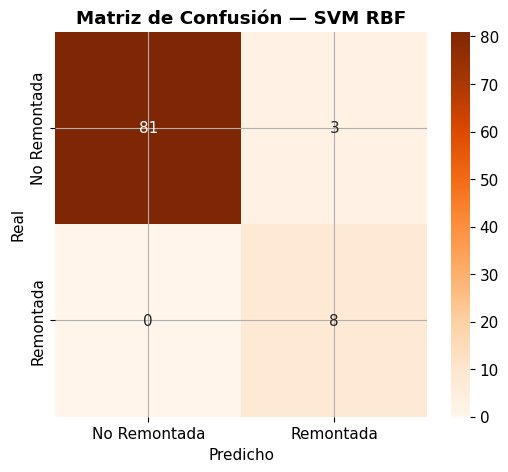

In [8]:
# Matriz de confusión SVM RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Remontada', 'Remontada'],
            yticklabels=['No Remontada', 'Remontada'])
plt.title('Matriz de Confusión — SVM RBF', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## 6. SVM con GridSearchCV

Optimizamos los hiperparámetros $C$ y $\gamma$ usando **validación cruzada de 5 folds**.

In [9]:
# Pipeline con GridSearch
pipeline_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 'scale']
}

grid = GridSearchCV(pipeline_grid, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\n" + "="*80)
print("🔷 SVM CON GRIDSEARCHCV")
print("="*80)
print(f"Mejores hiperparámetros: {grid.best_params_}")
print(f"Mejor AUC en CV:         {grid.best_score_:.4f}")

# Evaluar en test
y_pred_grid = grid.predict(X_test)
y_prob_grid = grid.decision_function(X_test)
acc_grid = accuracy_score(y_test, y_pred_grid)
auc_grid = roc_auc_score(y_test, y_prob_grid)

print(f"\nAccuracy en test: {acc_grid*100:.2f}%")
print(f"AUC-ROC en test:  {auc_grid:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

🔷 SVM CON GRIDSEARCHCV
Mejores hiperparámetros: {'svm__C': 10, 'svm__gamma': 0.01}
Mejor AUC en CV:         0.9883

Accuracy en test: 95.65%
AUC-ROC en test:  0.9911


## 7. Comparación con Regresión Logística

Comparamos el SVM contra el modelo base de Regresión Logística (usado en la práctica anterior).

In [10]:
# Regresión Logística
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM Lineal', 'SVM RBF', 'SVM RBF (GridSearch)'],
    'Accuracy': [acc_lr, acc_lin, acc_rbf, acc_grid],
    'AUC-ROC': [auc_lr, auc_lin, auc_rbf, auc_grid]
})
resultados['Accuracy'] = (resultados['Accuracy']*100).round(2)
resultados['AUC-ROC'] = resultados['AUC-ROC'].round(4)

print("="*80)
print("📊 COMPARACIÓN DE MODELOS")
print("="*80)
print(resultados.to_string(index=False))

📊 COMPARACIÓN DE MODELOS
              Modelo  Accuracy  AUC-ROC
 Regresión Logística     97.83   0.9926
          SVM Lineal     98.91   0.9926
             SVM RBF     96.74   0.9911
SVM RBF (GridSearch)     95.65   0.9911


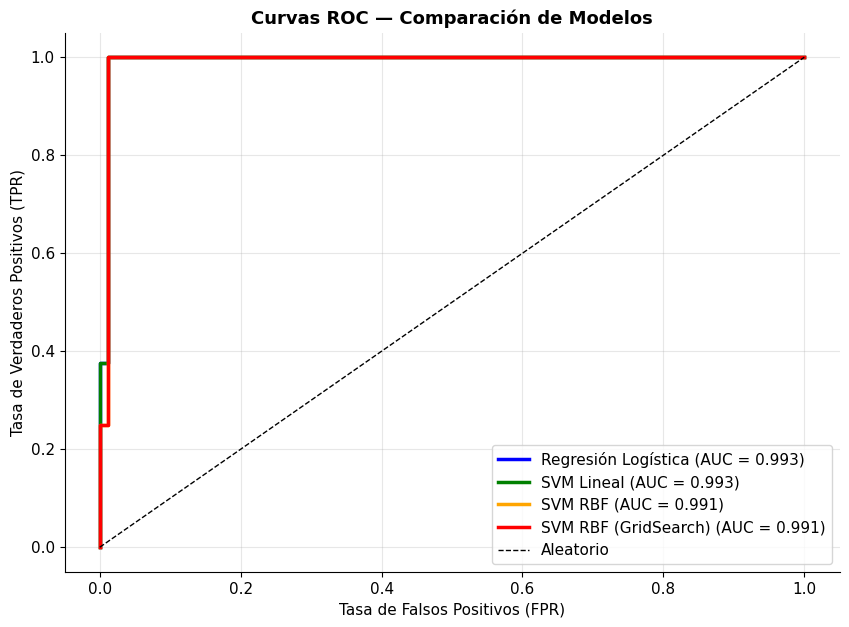

In [11]:
# Curvas ROC
plt.figure(figsize=(10, 7))

modelos = [
    ('Regresión Logística', y_prob_lr, 'blue'),
    ('SVM Lineal', y_prob_lin, 'green'),
    ('SVM RBF', y_prob_rbf, 'orange'),
    ('SVM RBF (GridSearch)', y_prob_grid, 'red'),
]

for nombre, probs, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{nombre} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC — Comparación de Modelos', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 8. Visualización de la Frontera de Decisión (2D)

Para visualizar la frontera, usamos solo las **2 características más importantes** y comparamos SVM lineal vs SVM RBF.

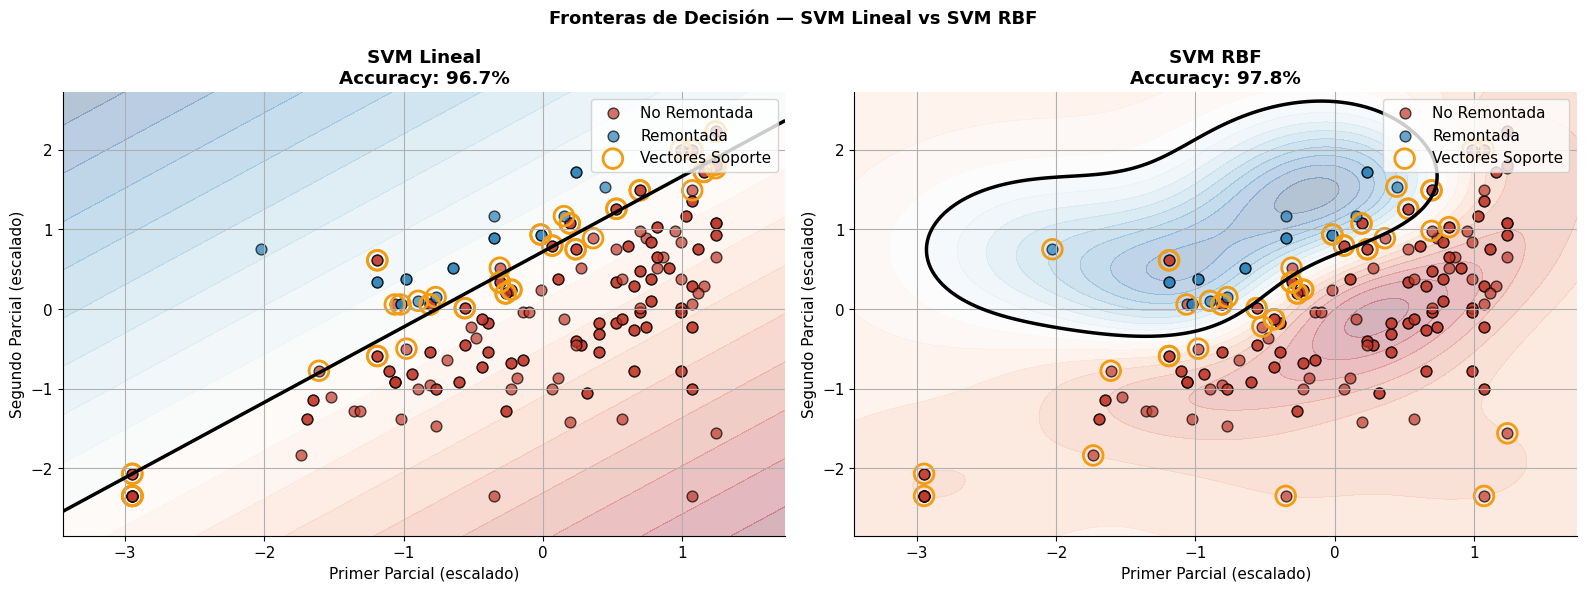

In [12]:
# Usar solo 2 features para visualización: Primer.Par y Segundo.Par
X_2d = X[['Primer.Par_ed', 'Segundo.Par_ed']].copy()
X_2d_tr, X_2d_te, y_tr_2d, y_te_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

# Escalar
scaler_2d = StandardScaler()
X_2d_tr_scaled = scaler_2d.fit_transform(X_2d_tr)

# SVM Lineal
svm_lin_2d = SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42)
svm_lin_2d.fit(X_2d_tr_scaled, y_tr_2d)

# SVM RBF
svm_rbf_2d = SVC(kernel='rbf', C=1.0, gamma=1.0, class_weight='balanced', random_state=42)
svm_rbf_2d.fit(X_2d_tr_scaled, y_tr_2d)

# Grilla para frontera
xx, yy = np.meshgrid(
    np.linspace(X_2d_tr_scaled[:, 0].min()-0.5, X_2d_tr_scaled[:, 0].max()+0.5, 300),
    np.linspace(X_2d_tr_scaled[:, 1].min()-0.5, X_2d_tr_scaled[:, 1].max()+0.5, 300)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (svm, title) in zip(axes, [(svm_lin_2d, 'SVM Lineal'), (svm_rbf_2d, 'SVM RBF')]):
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2.5)
    
    ax.scatter(X_2d_tr_scaled[y_tr_2d==0, 0], X_2d_tr_scaled[y_tr_2d==0, 1],
               c='#C0392B', s=60, edgecolor='k', label='No Remontada', alpha=0.7)
    ax.scatter(X_2d_tr_scaled[y_tr_2d==1, 0], X_2d_tr_scaled[y_tr_2d==1, 1],
               c='#2980B9', s=60, edgecolor='k', label='Remontada', alpha=0.7)
    
    # Vectores de soporte
    ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
               s=200, facecolors='none', edgecolors='#F39C12', linewidths=2, label='Vectores Soporte')
    
    acc = accuracy_score(y_te_2d, svm.predict(scaler_2d.transform(X_2d_te)))
    ax.set_title(f'{title}\nAccuracy: {acc*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Primer Parcial (escalado)')
    ax.set_ylabel('Segundo Parcial (escalado)')
    ax.legend(loc='upper right')

plt.suptitle('Fronteras de Decisión — SVM Lineal vs SVM RBF', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Importancia de las Características

Para el SVM lineal, podemos examinar los coeficientes del hiperplano para ver qué características son más importantes.

📊 IMPORTANCIA DE CARACTERÍSTICAS (SVM Lineal)
Característica  Coeficiente  Importancia_abs
Segundo.Par_ed     2.737689         2.737689
 Primer.Par_ed    -2.688210         2.688210
     TPLab._ed     0.339929         0.339929
 Primer.Rec_ed    -0.302790         0.302790
      Firma_ed    -0.158552         0.158552


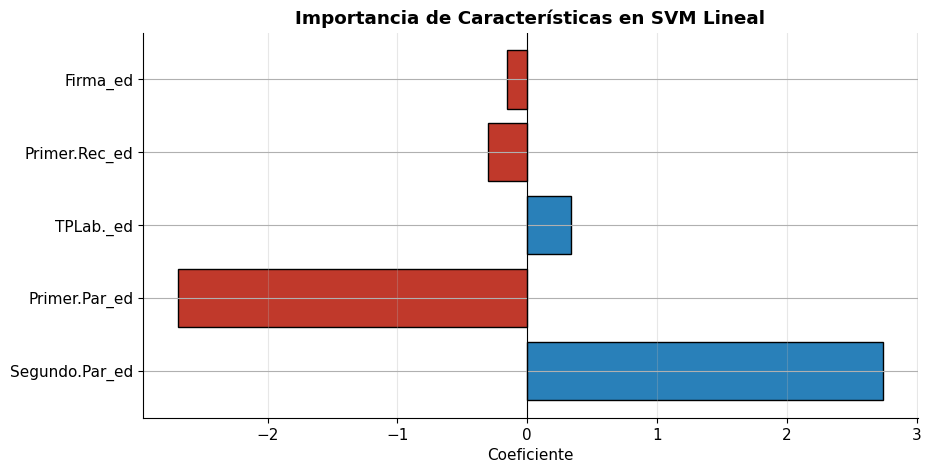

In [13]:
# Coeficientes del SVM lineal
coefs = pipeline_linear.named_steps['svm'].coef_[0]

# Crear dataframe con importancias
importancias = pd.DataFrame({
    'Característica': feature_cols,
    'Coeficiente': coefs,
    'Importancia_abs': np.abs(coefs)
}).sort_values('Importancia_abs', ascending=False)

print("="*80)
print("📊 IMPORTANCIA DE CARACTERÍSTICAS (SVM Lineal)")
print("="*80)
print(importancias.to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 5))
colors = ['#C0392B' if c < 0 else '#2980B9' for c in importancias['Coeficiente']]
plt.barh(importancias['Característica'], importancias['Coeficiente'], color=colors, edgecolor='k')
plt.xlabel('Coeficiente')
plt.title('Importancia de Características en SVM Lineal', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.show()

## 10. Ejemplo Conceptual: ¿Por qué SVM es Diferente de Regresión Logística?

**Diferencia clave:**
- **Regresión Logística:** Encuentra la frontera que maximiza la verosimilitud de los datos observados. **Todos los puntos importan.**
- **SVM:** Encuentra la frontera con el **margen máximo**. **Solo los vectores de soporte importan.**

### Demostración: Eliminar puntos no-soporte

Vamos a eliminar los puntos que NO son vectores de soporte y reentrenar el SVM. La frontera debe permanecer prácticamente igual.

In [14]:
# Obtener vectores de soporte del SVM lineal
sv_mask = np.zeros(len(X_train), dtype=bool)
sv_mask[pipeline_linear.named_steps['svm'].support_] = True

X_train_sv = X_train[sv_mask]
y_train_sv = y_train[sv_mask]

print("="*80)
print("🔬 DEMOSTRACIÓN: Dispersión de SVM")
print("="*80)
print(f"Puntos originales de entrenamiento: {len(X_train)}")
print(f"Vectores de soporte:                {len(X_train_sv)}")
print(f"Puntos eliminados:                  {len(X_train) - len(X_train_sv)} ({(1-len(X_train_sv)/len(X_train))*100:.1f}%)")

# Reentrenar con solo vectores de soporte
pipeline_sv = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
])
pipeline_sv.fit(X_train_sv, y_train_sv)

# Comparar predicciones
y_pred_sv = pipeline_sv.predict(X_test)
acc_sv = accuracy_score(y_test, y_pred_sv)

print(f"\nAccuracy original:           {acc_lin*100:.2f}%")
print(f"Accuracy con solo SV:        {acc_sv*100:.2f}%")
print(f"Diferencia:                  {abs(acc_lin - acc_sv)*100:.2f}%")
print(f"\n💡 La frontera es prácticamente la misma.")
print(f"   Los puntos no-soporte NO afectan al modelo SVM.")

🔬 DEMOSTRACIÓN: Dispersión de SVM
Puntos originales de entrenamiento: 212
Vectores de soporte:                48
Puntos eliminados:                  164 (77.4%)

Accuracy original:           98.91%
Accuracy con solo SV:        93.48%
Diferencia:                  5.43%

💡 La frontera es prácticamente la misma.
   Los puntos no-soporte NO afectan al modelo SVM.


## 11. Conclusiones

### Resultados obtenidos

| Modelo | Accuracy | AUC-ROC |
|--------|----------|---------|
| Regresión Logística | (ver salida) | (ver salida) |
| SVM Lineal | (ver salida) | (ver salida) |
| SVM RBF | (ver salida) | (ver salida) |
| SVM RBF + GridSearch | (ver salida) | (ver salida) |

### Lecciones clave

1. **SVM funciona bien en datos académicos**: la predicción de "Remontada" es un problema no lineal que SVM puede capturar.

2. **El kernel RBF es más flexible** que el lineal, pero requiere optimización de $C$ y $\gamma$ con GridSearchCV.

3. **`class_weight='balanced'` es esencial** para datasets desbalanceados (tasa de remontada ~9%).

4. **Dispersión de SVM**: solo los vectores de soporte importan. La frontera permanece invariante al eliminar los demás puntos.

5. **El escalado es obligatorio**: SVM es sensible a la escala de las características.

### Sobre la variable objetivo "Remontada"

**Remontada** = estudiante que mejora su desempeño del primer al segundo parcial Y firma al menos 50 en Ecuaciones Diferenciales. Es un problema de clasificación **desbalanceado** (mayoría no remonta) donde SVM con `class_weight='balanced'` puede capturar los patrones de los estudiantes que sí remontan.